In [3]:
import scipy
import numpy as np
import pandas as pd
import seaborn as sns
import seaborn.objects as so

from sklearn import linear_model    # Herramientas de modelos lineales
from sklearn.metrics import mean_squared_error, r2_score    # Medidas de desempeño
from sklearn.preprocessing import PolynomialFeatures    # Herramientas de polinomios
from sklearn.model_selection import train_test_split

from formulaic import Formula

## Ejercicio 1

El siguiente código genera un DataFrame noisyCircles con varios anillos de puntos.

Dar un código para realizar las siguientes tareas:
<ul>
<li>Agrupar los datos en la cantidad de clusters que considere apropiada, utilizando el método de clustering que considere apropiado</li>
<li>Graficar los datos coloreando los clusters según la etiqueta obtenida.</li>
<li>Contar la cantidad de puntos en el primer cluster (es decir los que tengan etiqueta 0).</li>
</ul>

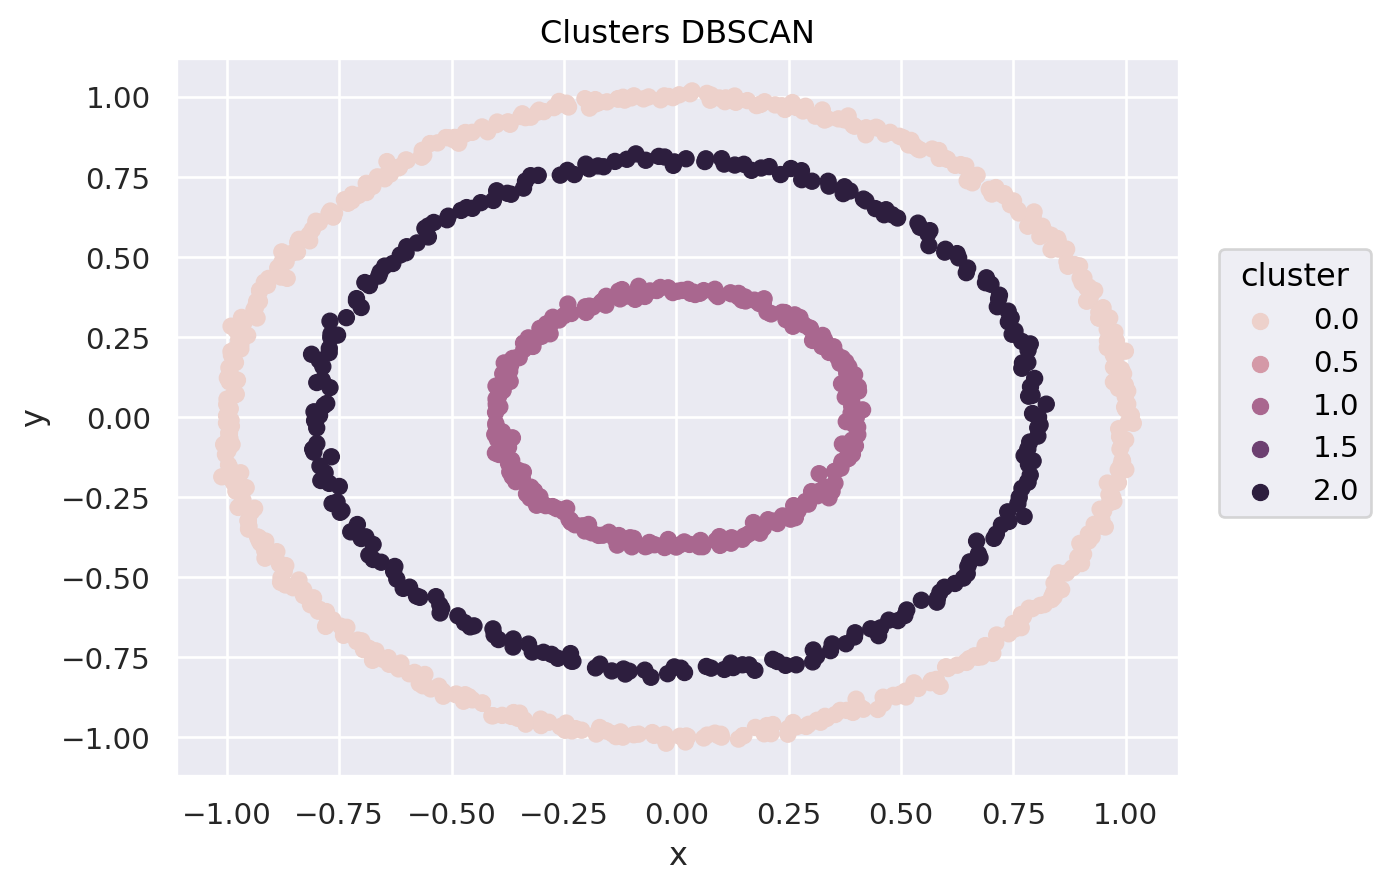

In [12]:
from sklearn import cluster, datasets


n_samples = 500
seed = 42
noisy_circles1 = pd.DataFrame(datasets.make_circles(n_samples=n_samples, factor=.4, noise=.01)[0])

noisy_circles2 = pd.DataFrame(datasets.make_circles(n_samples=n_samples, factor=.8, noise=.01)[0])

noisy_circles = pd.concat([noisy_circles1, noisy_circles2], axis = 0).reset_index(drop = True)
noisy_circles.columns=["x", "y"]

dbscan = cluster.DBSCAN(eps=0.1, min_samples=5)
labels = dbscan.fit_predict(noisy_circles[["x","y"]])

noisy_circles["cluster"] = labels

(
    so.Plot(noisy_circles, x="x", y="y", color = "cluster")
    .add(so.Dot())
    .label(title="Clusters DBSCAN")
)


## Ejercicio 6

A partir del DataSet penguins, dar un código de una sola línea para eliminar las filas con datos faltantes, resetear los índices (y "dropear" el original) y agregar "pinguinos_" al principio del nombre de todas las columnas.

Cargar el dataset con el siguiente codigo.

In [13]:
import seaborn as sns

penguins = sns.load_dataset('penguins')

penguins.dropna().reset_index(drop=True).add_prefix("pinguinos_")

,pinguinos_species,pinguinos_island,pinguinos_bill_length_mm,pinguinos_bill_depth_mm,pinguinos_flipper_length_mm,pinguinos_body_mass_g,pinguinos_sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
328,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
329,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
330,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
331,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


## Ejercicio 8
Para un Dataframe _data_ de 5 variables y 100 observaciones, dar un código para escalar linealmente cada columna al intervalo [0,5].

Es decir, el mínimo de cada columna debe ir al 0 y el máximo de cada columna debe ir al 5.

In [16]:
from sklearn.preprocessing import MinMaxScaler

np.random.seed(42)
data = pd.DataFrame(
    np.random.randn(100, 5) * [10, 1, 50, 5, 100] + [20, 0, 200, -10, 500],
    columns=["var1", "var2", "var3", "var4", "var5"]
)

scaler = MinMaxScaler(feature_range=(0,5))

data_scaled = pd.DataFrame(
    scaler.fit_transform(data),
    columns= data.columns
)

print(data_scaled.min())
print(data_scaled.max())

var1    0.0
var2    0.0
var3    0.0
var4    0.0
var5    0.0
dtype: float64
var1    5.0
var2    5.0
var3    5.0
var4    5.0
var5    5.0
dtype: float64


## Ejercicio 12

En el dataset tips de propinas, la variable size indica cuántos clientes había en la mesa y la variable total_bill indica cuánto gastaron en total en la mesa.

Agregar al dataset una columna client_bill que muestre lo que gastó cada cliente (considerando que se reparten el valor de la comida equitativamente) y otra columna lt_10 que indique si lo que gastó cada cliente fue menor que $10 (1 en caso afirmativo, 0 en caso negativo).

In [18]:
import seaborn as sns
tips = sns.load_dataset('tips')

In [20]:
tips['client_bill'] = tips.total_bill / tips["size"]
tips["lt_10"] = (tips.client_bill <10).astype(int)

## Ejercicio 16
Un DataFrame data contiene algunas columnas que comienzan con las letras "IMPO" y otras columnas que comienzan con "EXPO".
En un código de una sola línea, crear un nuevo DataFrame data_impo que contenga solo las columnas de data que comiencen con "IMPO".

In [ ]:
#data_expo = data[[col for col in data.columns if col.startswith("IMPO")]]

## Ejercicio 17
Ingresar un código para generar el siguiente gráfico a partir de datos del dataset tips

En el eje y se encuentra el total de propinas recibidas.

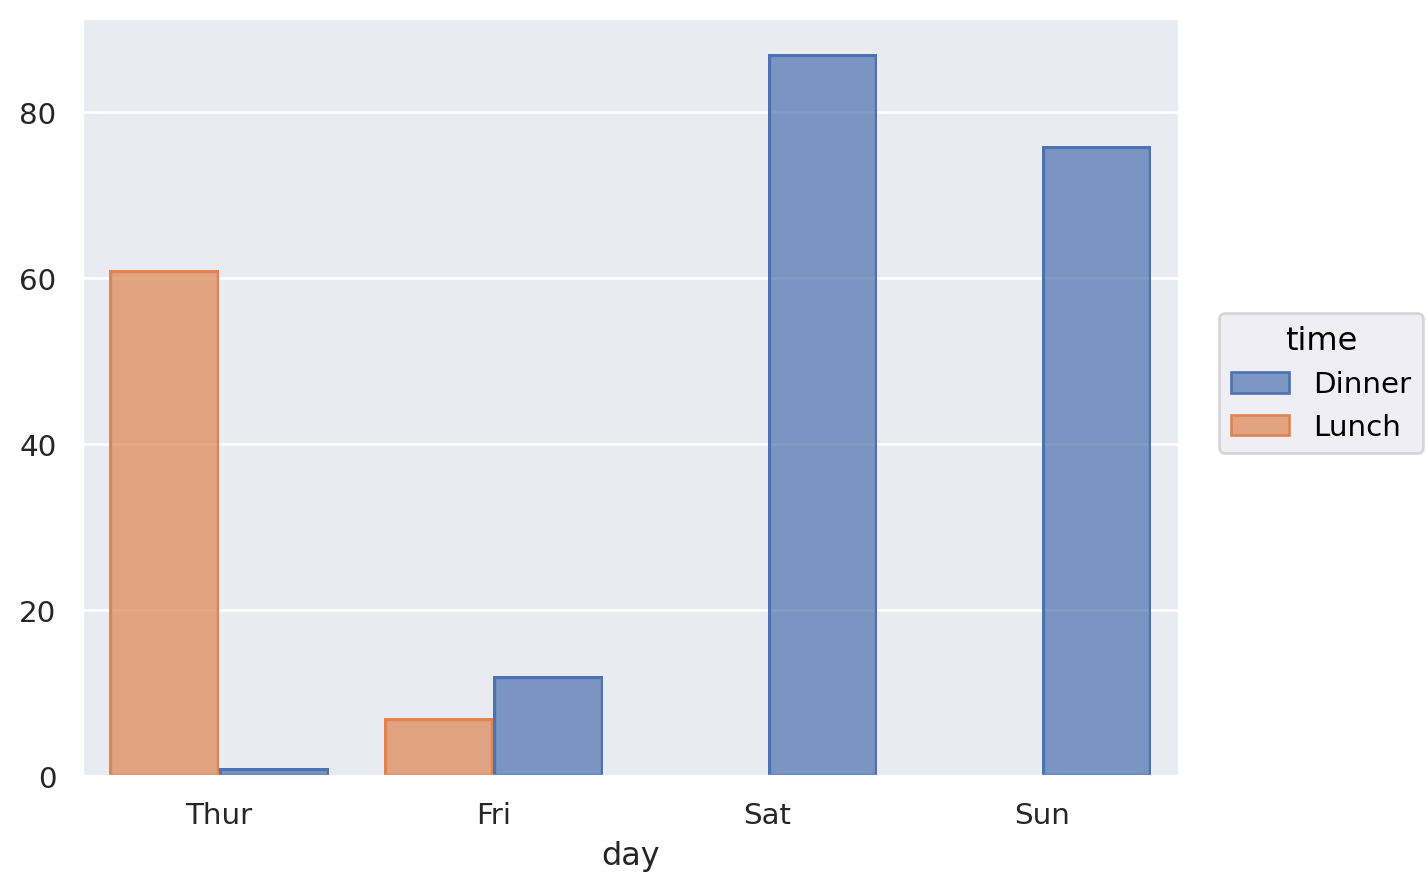

In [21]:
(
    so.Plot(tips,"day",color="time")
    .add(so.Bar(),so.Count(),so.Dodge())
)

## Ejercicio 6
### Solución alternativa

A partir del DataSet penguins, dar un código de una sola línea para eliminar las filas con datos faltantes, resetear los índices (y "dropear" el original) y agregar "pinguinos_" al principio del nombre de todas las columnas.



In [9]:
penguins = sns.load_dataset('penguins')

penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [13]:
penguins.dropna().reset_index(drop=True).rename(columns= lambda x :"pinguinos_" + x) 

,pinguinos_species,pinguinos_island,pinguinos_bill_length_mm,pinguinos_bill_depth_mm,pinguinos_flipper_length_mm,pinguinos_body_mass_g,pinguinos_sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
328,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
329,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
330,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
331,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


## Ejercicio 24
Ingresar un código para agregarle al dataset tips una columna llamada day_avg con el promedio de las cuentas (columna total_bill) del día (columna day). 

In [14]:
tips = sns.load_dataset('tips')

In [15]:
tips.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='str')

In [27]:
tips_promedio_dia = pd.Series(tips.groupby('day')['total_bill'].transform('mean'))

tips['day_avg'] = tips_promedio_dia



## Ejercicio 21

A partir de los datos de Gapminder se quiere calcular la mediana de los valores de PBI ("GDP") (el producto del PBI per cápita, gdpPerCap y su población, pop) en el año 1997.

¿Cuál es el código para hacerlo y cuál es el valor de la mediana?

In [30]:
gapminder = pd.read_csv('../../datasets/gapminder.csv')

gapminder


,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106
...,...,...,...,...,...,...
1699,Zimbabwe,Africa,1987,62.351,9216418,706.157306
1700,Zimbabwe,Africa,1992,60.377,10704340,693.420786
1701,Zimbabwe,Africa,1997,46.809,11404948,792.449960
1702,Zimbabwe,Africa,2002,39.989,11926563,672.038623


In [33]:
gdp1997 = gapminder[gapminder["year"] == 1997]

media_pbiPercap = gdp1997["gdpPercap"].median()
media_poblacion = gdp1997['pop'].median()

print(f"La mediana del pbi per cápita es: {media_pbiPercap:.2f}")
print(f"La mediana la poblacion es: {media_poblacion:.2f}")

La mediana del pbi per cápita es: 4781.83
La mediana la poblacion es: 9735063.50


## Ejercicio 22

Para el siguiente conjunto de 8 datos, se realiza un gráfico de dispersión de la matriz de datos centrados
X⋆=X−X¯
```

X = np.array([[1, 2], [2, -1], [3, -2], [4, 0], [2.5, 1], [3.7, 0.5], [1,0], [0,1]])
X_star = X - X.mean(axis = 0)
(
 so.Plot()
 .add(so.Dot(), x = X_star[:,0], y = X_star[:,1])
)
```

¿Cuál es la primera dirección principal
u1
y cuál es la proyección de los datos sobre esta dirección
z1
?

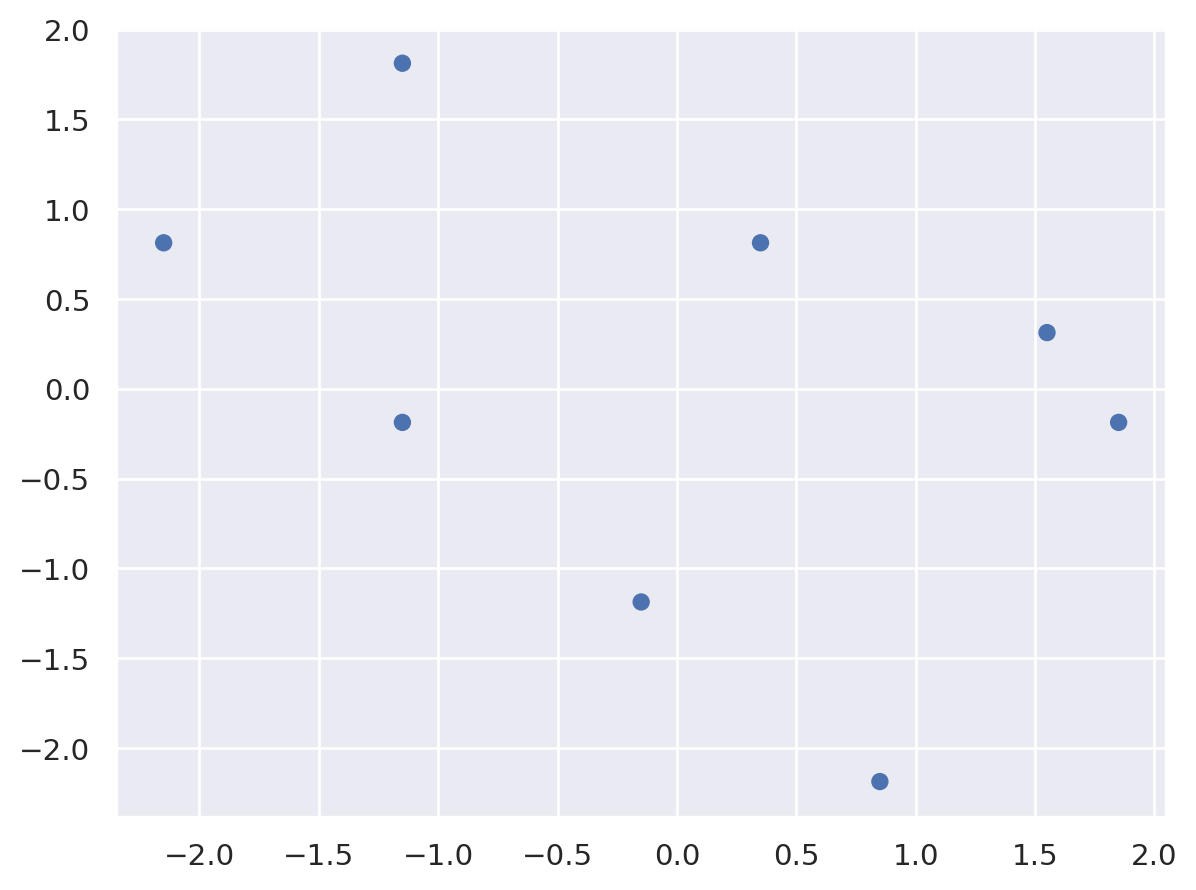

In [22]:
X = np.array([[1, 2], [2, -1], [3, -2], [4, 0], [2.5, 1], [3.7, 0.5], [1,0], [0,1]])
X_star = X - X.mean(axis = 0)
(
 so.Plot()
 .add(so.Dot(), x = X_star[:,0], y = X_star[:,1])
)

In [24]:
from sklearn.decomposition import PCA

pca = PCA(n_components=1).fit(X_star)
pca.components_[0].round(2)

array([ 0.8 , -0.59])

In [25]:
assert np.allclose(X_star @ pca.components_.T, pca.transform(X_star))
pca.transform(X_star).round(2).T

array([[-2.  ,  0.59,  1.98,  1.6 , -0.2 ,  1.06, -0.81, -2.21]])